In [1]:
# Cell 1: Load C-RADIOv4 Model and Measure Setup Time
import torch
import time
from transformers import AutoModel, CLIPImageProcessor

print("Starting C-RADIOv4-SO400M loading into memory...")
start_time = time.time()

# Local weights path (vad-project structure)
local_repo = "../models/c_radio_weights"

# Load visual processor
image_processor = CLIPImageProcessor.from_pretrained(local_repo)

# Load backbone with trust_remote_code
model = AutoModel.from_pretrained(local_repo, trust_remote_code=True)

# Optimize for inference: eval mode and move to GPU
model.eval().cuda()

end_time = time.time()
setup_time = end_time - start_time

print("-" * 50)
print("Model successfully loaded and ready on CUDA!")
print(f"Total cold start time: {setup_time:.2f} seconds")
print("-" * 50)

Starting C-RADIOv4-SO400M loading into memory...


Loading weights:   0%|          | 0/330 [00:00<?, ?it/s]

--------------------------------------------------
Model successfully loaded and ready on CUDA!
Total cold start time: 6.51 seconds
--------------------------------------------------


In [22]:
# Cell: Inspect C-RADIOv4 Outputs and Feature Shapes
import torch
from PIL import Image
import os

# Prendi uno dei tuoi frame con la bocca montata
test_image_path = "../data/extracted_frames/assembly_1_f0024.jpg" # O il nome esatto del tuo frame
if not os.path.exists(test_image_path):
    # Fallback al primo file disponibile nella directory corrente
    test_image_path = [f for f in os.listdir() if f.endswith('.jpg')][0]

print(f"Testing grounding features on: {test_image_path}")

image = Image.open(test_image_path).convert('RGB')

# Process image
inputs = image_processor(images=image, return_tensors='pt', do_resize=False)
pixel_values = inputs.pixel_values.to(dtype=torch.bfloat16, device='cuda')

with torch.no_grad():
    with torch.autocast('cuda', dtype=torch.bfloat16):
        # Forward pass del modello base
        # Di solito restituisce una tupla: (summary_tokens, dense_features) o simili
        outputs = model(pixel_values)

print("\n--- MODEL OUTPUT STRUCTURE ---")
if isinstance(outputs, tuple):
    for i, out in enumerate(outputs):
        print(f"Output element {i} shape: {out.shape if hasattr(out, 'shape') else type(out)}")
else:
    print(f"Output shape: {outputs.shape}")

print("-" * 30)

Testing grounding features on: ../data/extracted_frames/assembly_1_f0024.jpg

--- MODEL OUTPUT STRUCTURE ---
Output element 0 shape: torch.Size([1, 2304])
Output element 1 shape: torch.Size([1, 4096, 1152])
------------------------------


1. Extracting dense features for Frame 1 and Frame 2...

Mean Dense Cosine Similarity: 0.7594
Max Similarity: 0.9998 | Min Similarity: 0.4597



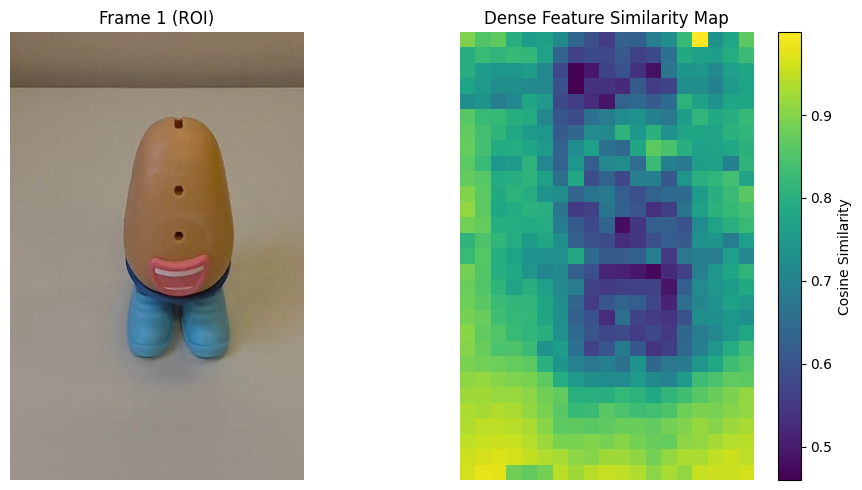

In [23]:
# Cell: Dense Feature Cosine Similarity Between Two Frames
import torch
import torch.nn.functional as F
from PIL import Image
import numpy as np
from einops import rearrange
import matplotlib.pyplot as plt

# Scegli due frame in cui lo scenario è lo stesso (es. entrambi con la bocca o entrambi vuoti)
path_frame1 = "../data/extracted_frames/assembly_1_f0024.jpg" # Frame A
path_frame2 = "../data/extracted_frames/assembly_2_f0022.jpg" # Frame B (o un altro frame simile)

def get_dense_grid(image_path):
    img = Image.open(image_path).convert('RGB')
    w, h = img.size
    
    # Usiamo la solita ROI della patata per pulire lo sfondo
    left, top, right, bottom = int(w * 0.35), int(h * 0.50), int(w * 0.65), int(h * 0.95)
    cropped = img.crop((left, top, right, bottom))
    
    nh, nw = model.get_nearest_supported_resolution(height=cropped.height, width=cropped.width)
    resized = cropped.resize((nw, nh), Image.Resampling.LANCZOS)
    
    inputs = image_processor(images=resized, return_tensors='pt', do_resize=False)
    pixel_values = inputs.pixel_values.to(dtype=torch.bfloat16, device='cuda')
    
    with torch.no_grad():
        with torch.autocast('cuda', dtype=torch.bfloat16):
            _, features = model(pixel_values) # shape: [1, 4096, 1152]
            
    patch_size = model.patch_size if hasattr(model, 'patch_size') else 16
    h_feat, w_feat = nh // patch_size, nw // patch_size
    
    # Riassestiamo in formato [Channels, Height, Width]
    grid = rearrange(features.squeeze(0), '(h w) d -> d h w', h=h_feat, w=w_feat).float()
    return grid, resized

print("1. Extracting dense features for Frame 1 and Frame 2...")
grid1, img1 = get_dense_grid(path_frame1)
grid2, img2 = get_dense_grid(path_frame2)

# 2. Calcoliamo la Cosine Similarity pixel-per-pixel (patch-per-patch) tra i due grigliati
# Assicuriamoci che abbiano le stesse dimensioni spaziali
if grid1.shape != grid2.shape:
    # Ridimensioniamo il secondo grigliato se le risoluzioni differiscono leggermente
    grid2 = F.interpolate(grid2.unsqueeze(0), size=(grid1.shape[1], grid1.shape[2]), mode='bilinear', align_corners=False).squeeze(0)

# Calcolo della similarità coseno lungo la dimensione dei canali (dim=0, i 1152 valori)
similarity_map = F.cosine_similarity(grid1, grid2, dim=0)

# Statistiche di base
mean_sim = similarity_map.mean().item()
max_sim = similarity_map.max().item()
min_sim = similarity_map.min().item()

print("\n" + "="*50)
print(f"Mean Dense Cosine Similarity: {mean_sim:.4f}")
print(f"Max Similarity: {max_sim:.4f} | Min Similarity: {min_sim:.4f}")
print("="*50 + "\n")

# --- PLOT DELLA MAPPA DI SIMILARITÀ ---
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.title("Frame 1 (ROI)")
plt.axis('off')

plt.subplot(1, 2, 2)
sim_np = similarity_map.cpu().numpy()
plt.imshow(sim_np, cmap='viridis', interpolation='nearest')
plt.colorbar(label="Cosine Similarity")
plt.title("Dense Feature Similarity Map")
plt.axis('off')

plt.tight_layout()
plt.show()

1. Extracting dense features for t0 and t1...

Intra-Video Mean Similarity: 0.9361
Min Similarity (The Action Spot): 0.7041



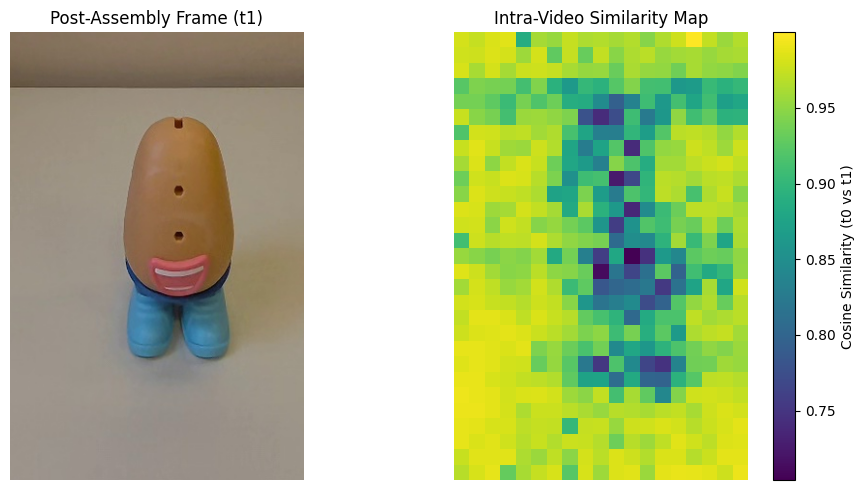

In [24]:
# Cell: Intra-Video Dense Feature Comparison (Pre vs Post Assembly)
import torch
import torch.nn.functional as F
from PIL import Image
import numpy as np
from einops import rearrange
import matplotlib.pyplot as plt

# Due frame dello STESSO video: uno prima dell'inserimento e uno dopo
path_t0 = "../data/extracted_frames/assembly_1_f0017.jpg" # Prima (bocca vuota)
path_t1 = "../data/extracted_frames/assembly_1_f0024.jpg" # Dopo (bocca inserita)

def get_dense_grid(image_path):
    img = Image.open(image_path).convert('RGB')
    w, h = img.size
    
    # Stessa ROI centrata sulla patata
    left, top, right, bottom = int(w * 0.35), int(h * 0.50), int(w * 0.65), int(h * 0.95)
    cropped = img.crop((left, top, right, bottom))
    
    nh, nw = model.get_nearest_supported_resolution(height=cropped.height, width=cropped.width)
    resized = cropped.resize((nw, nh), Image.Resampling.LANCZOS)
    
    inputs = image_processor(images=resized, return_tensors='pt', do_resize=False)
    pixel_values = inputs.pixel_values.to(dtype=torch.bfloat16, device='cuda')
    
    with torch.no_grad():
        with torch.autocast('cuda', dtype=torch.bfloat16):
            _, features = model(pixel_values) # shape: [1, 4096, 1152]
            
    patch_size = model.patch_size if hasattr(model, 'patch_size') else 16
    h_feat, w_feat = nh // patch_size, nw // patch_size
    
    grid = rearrange(features.squeeze(0), '(h w) d -> d h w', h=h_feat, w=w_feat).float()
    return grid, resized

print("1. Extracting dense features for t0 and t1...")
grid_t0, img_t0 = get_dense_grid(path_t0)
grid_t1, img_t1 = get_dense_grid(path_t1)

# 2. Calcoliamo la Cosine Similarity patch-per-patch tra t0 e t1
if grid_t0.shape != grid_t1.shape:
    grid_t1 = F.interpolate(grid_t1.unsqueeze(0), size=(grid_t0.shape[1], grid_t0.shape[2]), mode='bilinear', align_corners=False).squeeze(0)

similarity_map = F.cosine_similarity(grid_t0, grid_t1, dim=0)

mean_sim = similarity_map.mean().item()
min_sim = similarity_map.min().item()

print("\n" + "="*50)
print(f"Intra-Video Mean Similarity: {mean_sim:.4f}")
print(f"Min Similarity (The Action Spot): {min_sim:.4f}")
print("="*50 + "\n")

# --- PLOT ---
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_t1)
plt.title("Post-Assembly Frame (t1)")
plt.axis('off')

plt.subplot(1, 2, 2)
sim_np = similarity_map.cpu().numpy()
plt.imshow(sim_np, cmap='viridis', interpolation='nearest')
plt.colorbar(label="Cosine Similarity (t0 vs t1)")
plt.title("Intra-Video Similarity Map")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Cell: Intra-Video Dense Feature Comparison for Video B
import torch
import torch.nn.functional as F
from PIL import Image
import numpy as np
from einops import rearrange
import matplotlib.pyplot as plt

# Due frame del SECONDO video: prima e dopo l'assemblaggio
path_t0_B = "../data/extracted_frames/assembly_2_f0017.jpg" # Prima (bocca vuota)
path_t1_B = "../data/extracted_frames/assembly_2_f0022.jpg" # Dopo (bocca inserita)

def get_dense_grid(image_path):
    img = Image.open(image_path).convert('RGB')
    w, h = img.size
    
    left, top, right, bottom = int(w * 0.35), int(h * 0.50), int(w * 0.65), int(h * 0.95)
    cropped = img.crop((left, top, right, bottom))
    
    nh, nw = model.get_nearest_supported_resolution(height=cropped.height, width=cropped.width)
    resized = cropped.resize((nw, nh), Image.Resampling.LANCZOS)
    
    inputs = image_processor(images=resized, return_tensors='pt', do_resize=False)
    pixel_values = inputs.pixel_values.to(dtype=torch.bfloat16, device='cuda')
    
    with torch.no_grad():
        with torch.autocast('cuda', dtype=torch.bfloat16):
            _, features = model(pixel_values)
            
    patch_size = model.patch_size if hasattr(model, 'patch_size') else 16
    h_feat, w_feat = nh // patch_size, nw // patch_size
    
    grid = rearrange(features.squeeze(0), '(h w) d -> d h w', h=h_feat, w=w_feat).float()
    return grid, resized

print("1. Extracting dense features for Video B (t0 vs t1)...")
grid_t0_B, img_t0_B = get_dense_grid(path_t0_B)
grid_t1_B, img_t1_B = get_dense_grid(path_t1_B)

# Calcoliamo la Cosine Similarity patch-per-patch
if grid_t0_B.shape != grid_t1_B.shape:
    grid_t1_B = F.interpolate(grid_t1_B.unsqueeze(0), size=(grid_t0_B.shape[1], grid_t0_B.shape[2]), mode='bilinear', align_corners=False).squeeze(0)

similarity_map_B = F.cosine_similarity(grid_t0_B, grid_t1_B, dim=0)

mean_sim_B = similarity_map_B.mean().item()
min_sim_B = similarity_map_B.min().item()

print("\n" + "="*50)
print(f"Video B Mean Similarity: {mean_sim_B:.4f}")
print(f"Video B Min Similarity (Action Spot): {min_sim_B:.4f}")
print("="*50 + "\n")

# --- PLOT ---
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_t1_B)
plt.title("Video B - Post-Assembly (t1)")
plt.axis('off')

plt.subplot(1, 2, 2)
sim_np_B = similarity_map_B.cpu().numpy()
plt.imshow(sim_np_B, cmap='viridis', interpolation='nearest')
plt.colorbar(label="Cosine Similarity")
plt.title("Video B - Similarity Map")
plt.axis('off')

plt.tight_layout()
plt.show()

1. Processing Video A (Potato ROI)...
2. Processing Video B (Potato ROI)...
3. Computing Cosine Similarity...

Potato-Centric Action Similarity: -0.1595



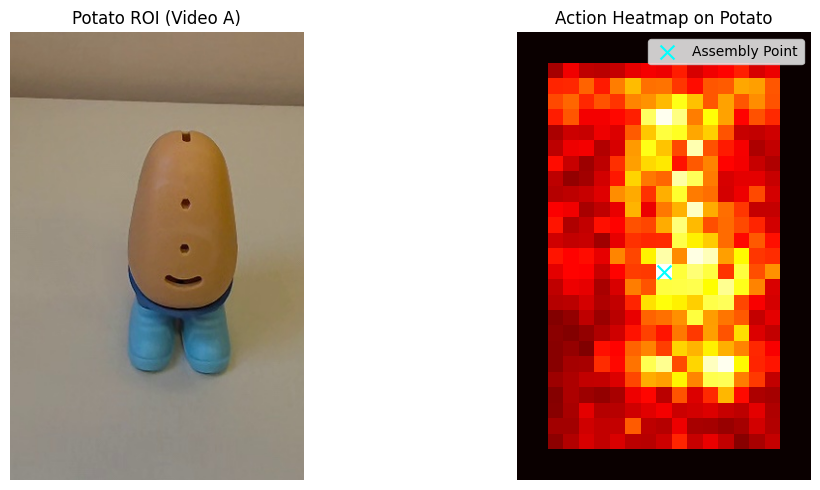

In [ ]:
# Cell 2: Potato-Centric State Change Detection (Manual ROI)
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
from einops import rearrange

# Paths to your extracted frames
paths = {
    "A_t0": "../data/extracted_frames/assembly_1_f0017.jpg", # Video 1 - Pre-assembly (use your exact filename)
    "A_t1": "../data/extracted_frames/assembly_1_f0024.jpg", # Video 1 - Post-assembly
    "B_t0": "../data/extracted_frames/assembly_2_f0017.jpg",   # Video 2 - Pre-assembly
    "B_t1": "../data/extracted_frames/assembly_2_f0022.jpg"    # Video 2 - Post-assembly
}

def extract_potato_grid(image_path):
    """
    Extracts the feature grid by forcing a crop exactly around the Mr. Potato body,
    simulating the bounding box that Unity will provide in production.
    """
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Missing file: {image_path}")
        
    image = Image.open(image_path).convert('RGB')
    w, h = image.size
    
    # HARDCODED ROI: We cut out the background and the loose parts on the table.
    # Adjust these percentages if the Potato is not perfectly in the center-bottom.
    left = int(w * 0.35)
    top = int(h * 0.50)
    right = int(w * 0.65)
    bottom = int(h * 0.95)
    
    img_cropped = image.crop((left, top, right, bottom))
    
    # Scale to optimal resolution
    nearest_h, nearest_w = model.get_nearest_supported_resolution(height=img_cropped.height, width=img_cropped.width)
    img_resized = img_cropped.resize((nearest_w, nearest_h), Image.Resampling.LANCZOS)
    
    # Forward pass
    inputs = image_processor(images=img_resized, return_tensors='pt', do_resize=False)
    pixel_values = inputs.pixel_values.to(dtype=torch.bfloat16, device='cuda')
    
    with torch.no_grad():
        with torch.autocast('cuda', dtype=torch.bfloat16):
            _, features = model(pixel_values)
            
    patch_size = model.patch_size if hasattr(model, 'patch_size') else 16
    h_feat, w_feat = nearest_h // patch_size, nearest_w // patch_size
    grid = rearrange(features.squeeze(0), '(h w) d -> d h w', h=h_feat, w=w_feat).float()
    
    return grid, img_resized

print("1. Processing Video A (Potato ROI)...")
grid_A_t0, img_A = extract_potato_grid(paths["A_t0"])
grid_A_t1, _     = extract_potato_grid(paths["A_t1"])

# Delta on the Potato ONLY
delta_A = grid_A_t1 - grid_A_t0
magnitude_A = torch.norm(delta_A, dim=0)

print("2. Processing Video B (Potato ROI)...")
grid_B_t0, img_B = extract_potato_grid(paths["B_t0"])
grid_B_t1, _     = extract_potato_grid(paths["B_t1"])

# Delta on the Potato ONLY
delta_B = grid_B_t1 - grid_B_t0
magnitude_B = torch.norm(delta_B, dim=0)

# Mask edges to prevent ViT artifacts
margin = 2
magnitude_A[:margin, :] = 0; magnitude_A[-margin:, :] = 0
magnitude_A[:, :margin] = 0; magnitude_A[:, -margin:] = 0
magnitude_B[:margin, :] = 0; magnitude_B[-margin:, :] = 0
magnitude_B[:, :margin] = 0; magnitude_B[:, -margin:] = 0

# Find action vector
max_y_A, max_x_A = np.unravel_index(torch.argmax(magnitude_A).cpu().numpy(), magnitude_A.shape)
action_vector_A = delta_A[:, max_y_A, max_x_A]

max_y_B, max_x_B = np.unravel_index(torch.argmax(magnitude_B).cpu().numpy(), magnitude_B.shape)
action_vector_B = delta_B[:, max_y_B, max_x_B]

print("3. Computing Cosine Similarity...")
similarity = F.cosine_similarity(action_vector_A.unsqueeze(0), action_vector_B.unsqueeze(0))

print("\n" + "="*50)
print(f"Potato-Centric Action Similarity: {similarity.item():.4f}")
print("="*50 + "\n")

# --- PLOTTING ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_A)
plt.title("Potato ROI (Video A)")
plt.axis('off')

plt.subplot(1, 2, 2)
heatmap = magnitude_A.cpu().numpy()
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
plt.imshow(heatmap, cmap='hot', interpolation='nearest')
plt.scatter([max_x_A], [max_y_A], color='cyan', marker='x', s=100, label='Assembly Point')
plt.title("Action Heatmap on Potato")
plt.legend()
plt.axis('off')
plt.tight_layout()
plt.show()

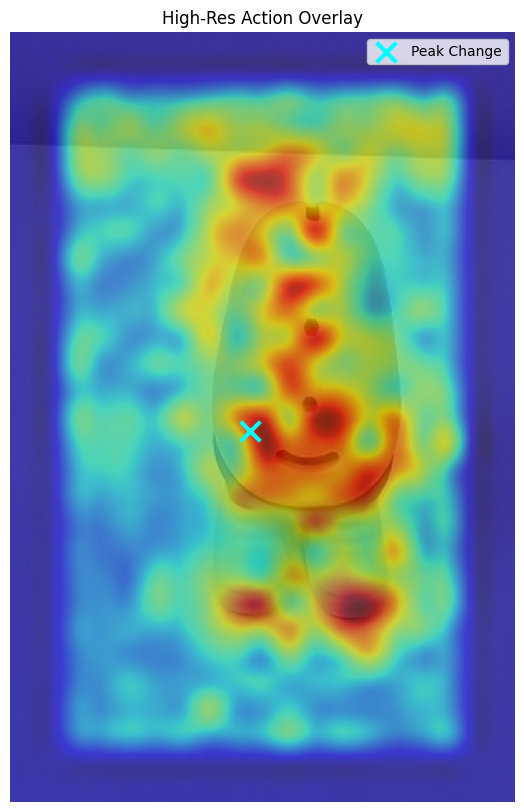

In [10]:
# Cell 3: High-Definition Overlay Plot
import cv2

plt.figure(figsize=(10, 10))

# Interpolazione bicubica della heatmap per portarla alla risoluzione dell'immagine originale
heatmap_resized = cv2.resize(heatmap, (img_A.width, img_A.height), interpolation=cv2.INTER_CUBIC)

# Mostra l'immagine originale e la heatmap in sovrimpressione (alpha regola la trasparenza)
plt.imshow(img_A)
plt.imshow(heatmap_resized, cmap='jet', alpha=0.6)

# Ricalcola le coordinate del picco scalate sulla nuova risoluzione
scale_x = img_A.width / magnitude_A.shape[1]
scale_y = img_A.height / magnitude_A.shape[0]
plt.scatter([max_x_A * scale_x], [max_y_A * scale_y], color='cyan', marker='x', s=200, linewidths=3, label='Peak Change')

plt.title("High-Res Action Overlay")
plt.legend()
plt.axis('off')
plt.show()

1. Extracting Grids...
2. Computing Mask-Pooled Cosine Similarity...

Mask-Pooled Action Similarity: 0.0231



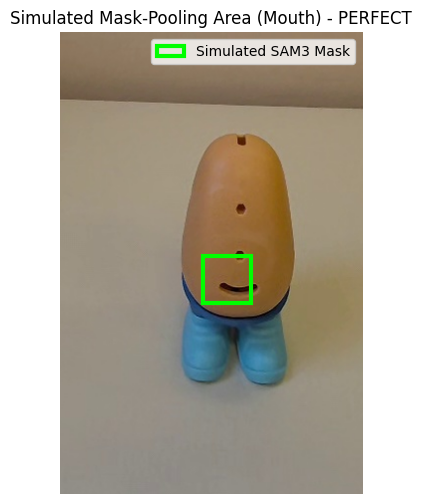

In [15]:
# Cell 4: Simulated Mask-Pooling (O-VAD Style)
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
from einops import rearrange
import matplotlib.patches as patches

# Paths to your extracted frames
paths = {
    "A_t0": "../data/extracted_frames/assembly_1_f0017.jpg",
    "A_t1": "../data/extracted_frames/assembly_1_f0024.jpg",
    "B_t0": "../data/extracted_frames/assembly_2_f0017.jpg",
    "B_t1": "../data/extracted_frames/assembly_2_f0022.jpg"
}

def extract_potato_grid(image_path):
    """
    Extracts the feature grid using the Potato ROI crop.
    """
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Missing file: {image_path}")
        
    image = Image.open(image_path).convert('RGB')
    w, h = image.size
    
    left = int(w * 0.35)
    top = int(h * 0.50)
    right = int(w * 0.65)
    bottom = int(h * 0.95)
    img_cropped = image.crop((left, top, right, bottom))
    
    nearest_h, nearest_w = model.get_nearest_supported_resolution(height=img_cropped.height, width=img_cropped.width)
    img_resized = img_cropped.resize((nearest_w, nearest_h), Image.Resampling.LANCZOS)
    
    inputs = image_processor(images=img_resized, return_tensors='pt', do_resize=False)
    pixel_values = inputs.pixel_values.to(dtype=torch.bfloat16, device='cuda')
    
    with torch.no_grad():
        with torch.autocast('cuda', dtype=torch.bfloat16):
            _, features = model(pixel_values)
            
    patch_size = model.patch_size if hasattr(model, 'patch_size') else 16
    h_feat, w_feat = nearest_h // patch_size, nearest_w // patch_size
    grid = rearrange(features.squeeze(0), '(h w) d -> d h w', h=h_feat, w=w_feat).float()
    
    return grid, img_resized

print("1. Extracting Grids...")
grid_A_t0, img_A = extract_potato_grid(paths["A_t0"])
grid_A_t1, _     = extract_potato_grid(paths["A_t1"])
grid_B_t0, img_B = extract_potato_grid(paths["B_t0"])
grid_B_t1, _     = extract_potato_grid(paths["B_t1"])

# Calculate Deltas
delta_A = grid_A_t1 - grid_A_t0
delta_B = grid_B_t1 - grid_B_t0

# 2. Simulate SAM3 Mask (Targeting the Mouth Area - FINAL TUNE)
h_feat, w_feat = delta_A.shape[1], delta_A.shape[2]

# Spostiamo il box più a destra (da 48% a 72%) e lo stringiamo verticalmente
y_start, y_end = int(h_feat * 0.50), int(h_feat * 0.60)
x_start, x_end = int(h_feat * 0.48), int(h_feat * 0.65) # Usiamo w_feat per la larghezza

# Correzione pulita per X usando w_feat:
x_start, x_end = int(w_feat * 0.48), int(w_feat * 0.65)

# 3. Apply Mask-Pooling (Mean Pooling inside the mask)
pooled_delta_A = delta_A[:, y_start:y_end, x_start:x_end].mean(dim=(1, 2))
pooled_delta_B = delta_B[:, y_start:y_end, x_start:x_end].mean(dim=(1, 2))

print("2. Computing Mask-Pooled Cosine Similarity...")
similarity = F.cosine_similarity(pooled_delta_A.unsqueeze(0), pooled_delta_B.unsqueeze(0))

print("\n" + "="*50)
print(f"Mask-Pooled Action Similarity: {similarity.item():.4f}")
print("="*50 + "\n")

# --- PLOTTING ---
plt.figure(figsize=(6, 6))
plt.imshow(img_A)

patch_size = model.patch_size if hasattr(model, 'patch_size') else 16
px_x = x_start * patch_size
px_y = y_start * patch_size
px_w = (x_end - x_start) * patch_size
px_h = (y_end - y_start) * patch_size

rect = patches.Rectangle((px_x, px_y), px_w, px_h, linewidth=3, edgecolor='lime', facecolor='none', label='Simulated SAM3 Mask')
plt.gca().add_patch(rect)
plt.title("Simulated Mask-Pooling Area (Mouth) - PERFECT")
plt.legend()
plt.axis('off')
plt.show()

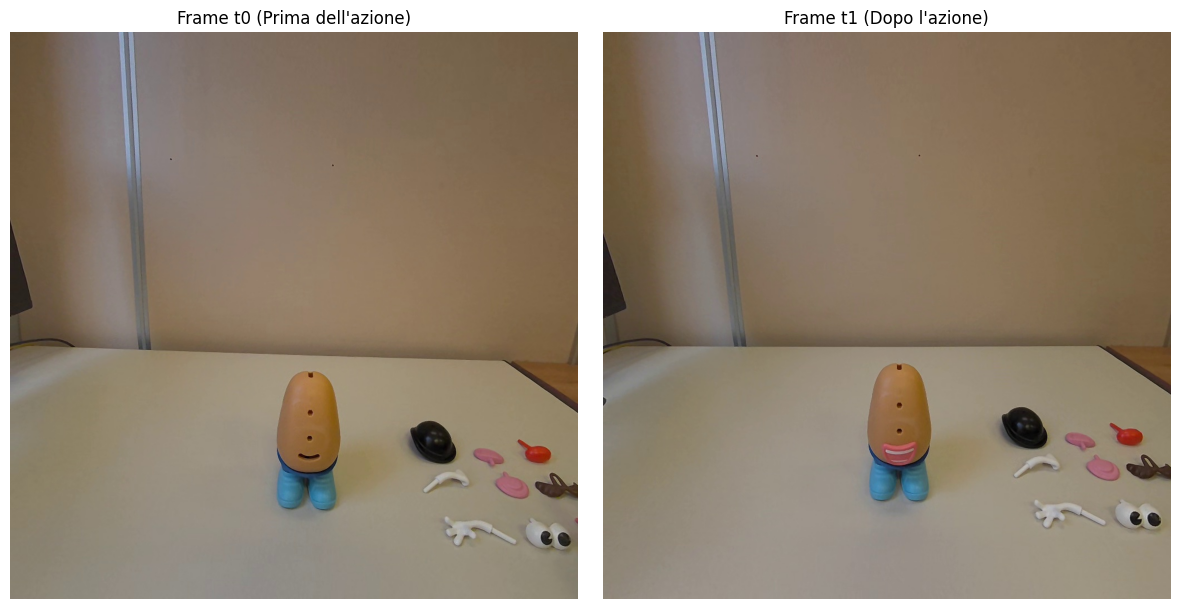

In [18]:
# Cell 5: Visualize exact Pre and Post assembly frames with Correct Mask
import matplotlib.pyplot as plt
from PIL import Image
import os

# Carichiamo direttamente i due frame specifici del Video 1
frame_t0_path = "../data/extracted_frames/assembly_1_f0017.jpg" # Prima dell'azione
frame_t1_path = "../data/extracted_frames/assembly_1_f0024.jpg" # Dopo l'azione

if not os.path.exists(frame_t0_path) or not os.path.exists(frame_t1_path):
    raise FileNotFoundError("Assicurati che i file dei frame siano nella stessa cartella del notebook!")

img_t0 = Image.open(frame_t0_path).convert('RGB')
img_t1 = Image.open(frame_t1_path).convert('RGB')

# Visualizziamo i due frame affiancati per capire visivamente la differenza
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_t0)
axes[0].set_title("Frame t0 (Prima dell'azione)")
axes[0].axis('off')

axes[1].imshow(img_t1)
axes[1].set_title("Frame t1 (Dopo l'azione)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [21]:
# Cell: Sequential Frame-by-Frame Action Delta Analysis
import torch
import torch.nn.functional as F
from PIL import Image
import numpy as np
import os
from einops import rearrange

# List of exact sequential frames for the action window provided
frame_files = [
    "../data/extracted_frames/assembly_1_f0017.jpg",
    "../data/extracted_frames/assembly_1_f0018.jpg",
    "../data/extracted_frames/assembly_1_f0019.jpg",
    "../data/extracted_frames/assembly_1_f0020.jpg",
    "../data/extracted_frames/assembly_1_f0021.jpg",
    "../data/extracted_frames/assembly_1_f0022.jpg",
    "../data/extracted_frames/assembly_1_f0023.jpg",
    "../data/extracted_frames/assembly_1_f0024.jpg"
]

def get_mouth_pooled_feature(image_path):
    """
    Extracts the grid, applies potato ROI, and mask-pools 
    specifically the mouth region.
    """
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Missing file: {image_path}")
        
    img = Image.open(image_path).convert('RGB')
    w, h = img.size
    
    # 1. Potato ROI Crop
    left, top, right, bottom = int(w * 0.35), int(h * 0.50), int(w * 0.65), int(h * 0.95)
    cropped = img.crop((left, top, right, bottom))
    
    nh, nw = model.get_nearest_supported_resolution(height=cropped.height, width=cropped.width)
    resized = cropped.resize((nw, nh), Image.Resampling.LANCZOS)
    
    # 2. Forward pass through C-RADIOv4
    inputs = image_processor(images=resized, return_tensors='pt', do_resize=False)
    pixel_values = inputs.pixel_values.to(dtype=torch.bfloat16, device='cuda')
    
    with torch.no_grad():
        with torch.autocast('cuda', dtype=torch.bfloat16):
            _, features = model(pixel_values)
            
    patch_size = model.patch_size if hasattr(model, 'patch_size') else 16
    grid = rearrange(features.squeeze(0), '(h w) d -> d h w', h=nh//patch_size, w=nw//patch_size).float()
    
    # 3. Exact Mouth Mask-Pooling Coordinates
    h_f, w_f = grid.shape[1], grid.shape[2]
    y_start, y_end = int(h_f * 0.50), int(h_f * 0.60)
    x_start, x_end = int(w_f * 0.48), int(w_f * 0.65)
    
    # Average features inside the mouth mask area into a single vector
    pooled_vector = grid[:, y_start:y_end, x_start:x_end].mean(dim=(1, 2))
    return pooled_vector

print("Extracting features across the action timeline...")
features_seq = []
for f in frame_files:
    vec = get_mouth_pooled_feature(f)
    features_seq.append(vec)

print("\n--- TIMELINE DELTA ANALYSIS ---")
# Compute feature distance (L2 norm) between consecutive frames
for i in range(len(features_seq) - 1):
    curr_frame = frame_files[i]
    next_frame = frame_files[i+1]
    
    delta_magnitude = torch.norm(features_seq[i+1] - features_seq[i]).item()
    print(f"Transition {curr_frame} -> {next_frame} | Delta: {delta_magnitude:.4f}")

print("-" * 33)

Extracting features across the action timeline...

--- TIMELINE DELTA ANALYSIS ---
Transition ../data/extracted_frames/assembly_1_f0017.jpg -> ../data/extracted_frames/assembly_1_f0018.jpg | Delta: 10.2522
Transition ../data/extracted_frames/assembly_1_f0018.jpg -> ../data/extracted_frames/assembly_1_f0019.jpg | Delta: 12.3082
Transition ../data/extracted_frames/assembly_1_f0019.jpg -> ../data/extracted_frames/assembly_1_f0020.jpg | Delta: 16.7464
Transition ../data/extracted_frames/assembly_1_f0020.jpg -> ../data/extracted_frames/assembly_1_f0021.jpg | Delta: 12.5490
Transition ../data/extracted_frames/assembly_1_f0021.jpg -> ../data/extracted_frames/assembly_1_f0022.jpg | Delta: 5.1266
Transition ../data/extracted_frames/assembly_1_f0022.jpg -> ../data/extracted_frames/assembly_1_f0023.jpg | Delta: 8.0340
Transition ../data/extracted_frames/assembly_1_f0023.jpg -> ../data/extracted_frames/assembly_1_f0024.jpg | Delta: 9.8939
---------------------------------
